In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np 

#### Load DATA 

In [3]:
df = pd.read_csv(
    "C:/Users/Pratiksha Swami/Downloads/archive/superstore_final_dataset.csv",
    encoding='ISO-8859-1'
)

### DATA Cleaning 

In [6]:
df

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [11]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

In [12]:
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

In [13]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [14]:
df['Postal_Code'] = df['Postal_Code'].fillna(0)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.describe()

,Row_ID,Order_Date,Ship_Date,Postal_Code,Sales
count,9800.000000,9800,9800,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55211.280918,230.769059
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,0.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,57551.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32076.677954,626.651875


## KPI revenue, profit margin, average order value, conversion metrics 

profit margin can not be calculated because in dataset i dont have profit data in the database

In [21]:
# REVENUE
total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 2261536.7827


In [23]:
aov = df['Sales'].sum() / df['Order_ID'].nunique()
print(f"AOV: ₹{aov:,.0f}")

AOV: ₹459


In [25]:
# Conversion metric orders per customer_id
conversion_metric = df['Order_ID'].nunique() / df['Customer_ID'].nunique()
print("Orders per Customer:", conversion_metric)

Orders per Customer: 6.206809583858764


“Key performance indicators including total revenue, average order value, and customer purchasing behavior were calculated.

### DATA VISUALIZATIONS

In [34]:
#### SALES TREND

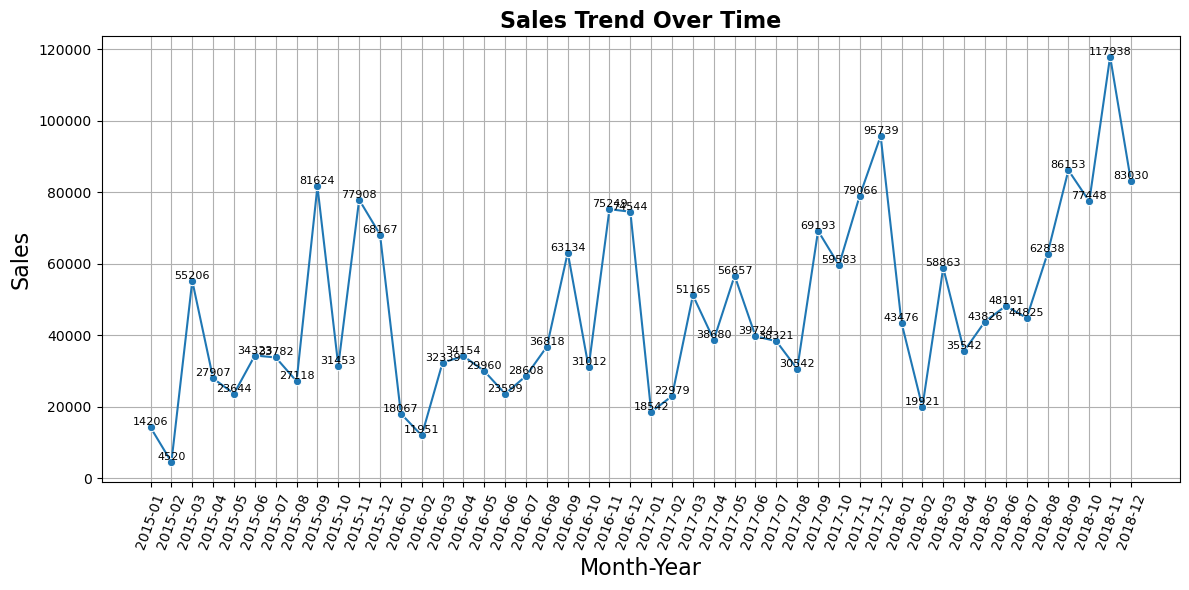

In [35]:
# Extract month-year
df['Month_Year'] = df['Order_Date'].dt.to_period('M')

# Group data
trend = df.groupby('Month_Year')['Sales'].sum().reset_index()

# Convert to string for plotting
trend['Month_Year'] = trend['Month_Year'].astype(str)

# Plot
plt.figure(figsize=(12,6))

ax = sns.lineplot(data=trend, x='Month_Year', y='Sales', marker='o')

plt.xticks(rotation=70)

# Labels
for x, y in zip(trend['Month_Year'], trend['Sales']):
    plt.text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=8)
plt.grid()
plt.title("Sales Trend Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Month-Year",fontsize=16)
plt.ylabel("Sales",fontsize=16)

plt.tight_layout()
plt.show()

The sales trend over the three-year period shows noticeable fluctuations, indicating seasonal patterns. Sales reached their highest peak in November 2018, followed by a second-highest peak in December 2017.

The lowest sales were observed in February 2015. Additionally, sales tend to be lower at the beginning of each year, particularly in the early months, suggesting a seasonal dip in customer demand.

Overall, the analysis indicates strong seasonality, with higher sales during the end of the year and lower sales at the start.
This pattern suggests that businesses can benefit from targeted promotions and campaigns during low-sales periods to balance revenue throughout the year.

In [36]:
# TOP PRODUCTS

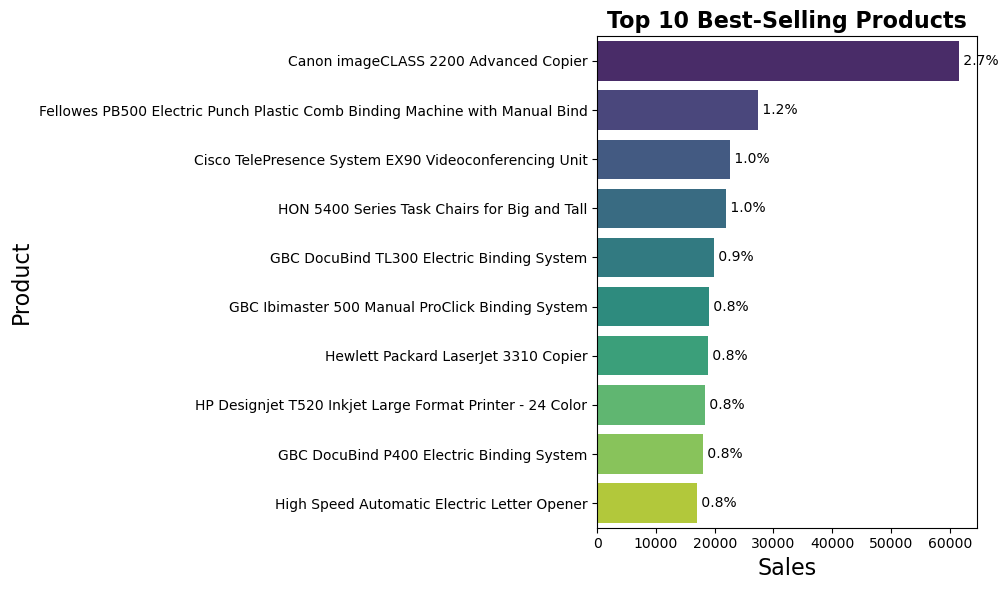

In [45]:
top_products = df.groupby('Product_Name')['Sales'].sum() \
                .sort_values(ascending=False).head(10).reset_index()
total_sales = df['Sales'].sum()

top_products['Percentage'] = (top_products['Sales'] / total_sales) * 100
plt.figure(figsize=(10,6))

ax = sns.barplot(data=top_products,x='Sales',y='Product_Name',hue='Product_Name',palette='viridis')

for i, (value, percent) in enumerate(zip(top_products['Sales'], top_products['Percentage'])):
    ax.text(value, i, f' {percent:.1f}%', va='center')


plt.title("Top 10 Best-Selling Products", fontsize=16, fontweight='bold')
plt.xlabel("Sales", fontsize=16)
plt.ylabel("Product", fontsize=16)

plt.tight_layout()
plt.show()

The bar chart highlights the top 10 best-selling products based on their contribution to total sales. The Canon imageCLASS 2200 Advanced Copier is the highest contributor, accounting for approximately 2.7% of overall sales.

In contrast, the lowest-performing product among the top 10 contributes around 0.8%.

This indicates that even the top-performing products individually contribute a relatively small percentage, suggesting that revenue is distributed across multiple products rather than being dominated by a single item

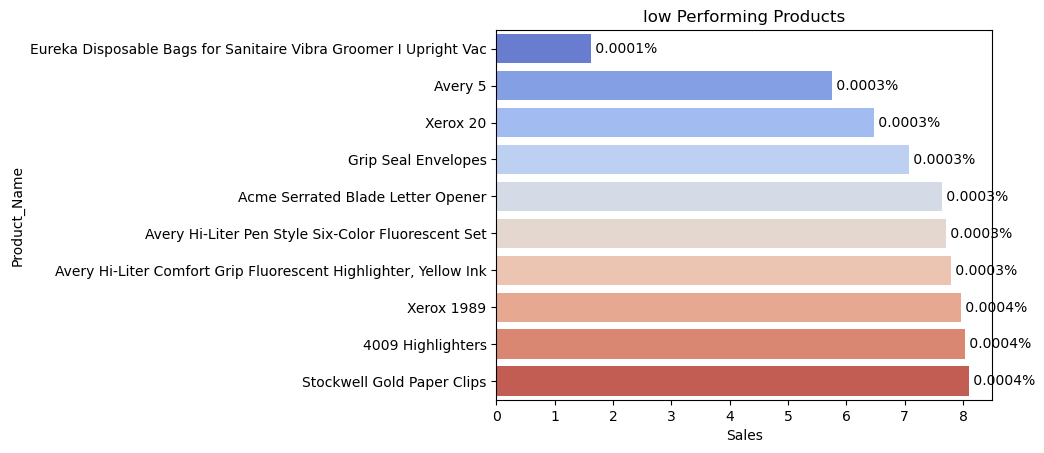

In [52]:
low_products = df.groupby('Product_Name')['Sales'].sum() \
                  .sort_values().head(10).reset_index()
total_sales = df['Sales'].sum()

low_products['Percentage'] = (low_products['Sales'] / total_sales) * 100
ax=sns.barplot(data=low_products, x='Sales', y='Product_Name',hue='Product_Name', palette='coolwarm')

for i, (value, percent) in enumerate(zip(low_products['Sales'], low_products['Percentage'])):
    ax.text(value, i, f' {percent:.4f}%', va='center')
    
plt.title("low Performing Products")
plt.show()

In [53]:
# REGIONAL PERFORMACE 

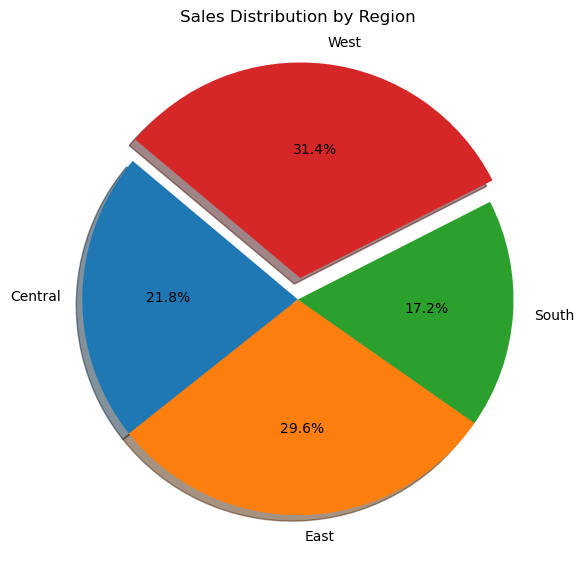

In [66]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7,7))

plt.pie(region_sales,labels=region_sales.index,autopct='%1.1f%%',startangle=140,shadow=1,explode=[0,0,0,0.1])

plt.title("Sales Distribution by Region")

plt.show()

The regional sales distribution reveals that the West region dominates overall revenue contribution, making it the most significant market. Conversely, the South region contributes the least, highlighting potential opportunities for growth through targeted marketing and expansion strategies.

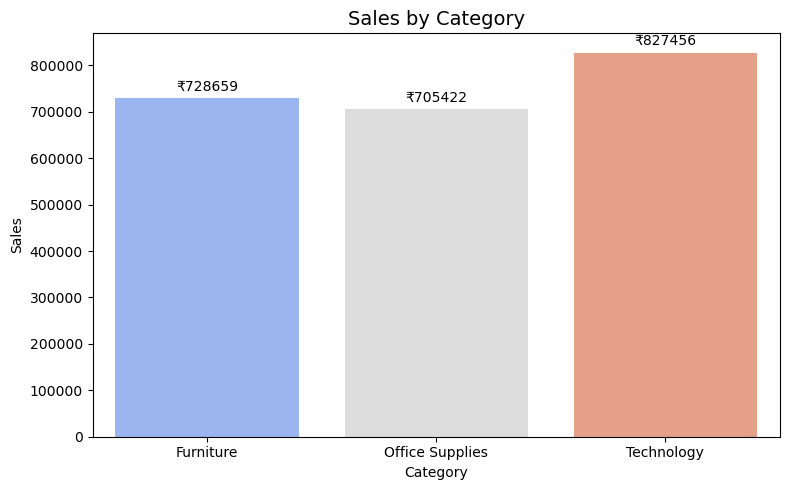

In [70]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(data=category_sales,x='Category',y='Sales',hue='Category',palette='coolwarm',legend=False)

# Add sales labels
for container in ax.containers:
    ax.bar_label(container, fmt='₹%.0f', padding=3)

plt.title("Sales by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

The analysis of category-wise sales shows that the Technology category generates the highest revenue, making it the leading contributor to overall business performance. This suggests a strong customer preference for technology products compared to other categories.

## FINAL RECOMMENDATIONS & SUGGESTIONS
1. Focus on High-Performing Regions

The West region contributes the highest share of sales. The company should strengthen its presence in this region through targeted marketing campaigns, better customer engagement, and inventory availability to maximize revenue.

2. Improve Low-Performing Regions

The South region shows the lowest sales contribution. The company should analyze customer preferences, improve marketing strategies, and consider regional promotions or discounts to boost performance in this area.

3. Promote Top-Selling Products

A small number of products contribute significantly to total sales. These top-performing products should be prioritized in marketing campaigns, bundled offers, and advertisements to further increase revenue.

4. Optimize or Remove Low-Performing Products

Products with very low sales contribution have minimal impact on overall revenue. The company should evaluate whether to improve their visibility, adjust pricing, or discontinue them to reduce costs and improve efficiency.

5. Leverage Seasonal Trends

Sales show clear seasonal patterns, with higher sales towards the end of the year and lower sales at the beginning. The company should introduce promotions, discounts, and campaigns during low-sales periods to maintain consistent revenue throughout the year.

6. Focus on High-Revenue Categories

The Technology category contributes the highest revenue. The company should expand product offerings, improve inventory, and invest more in this category to maximize profitability.

7. Enhance Customer Purchase Behavior

Since repeat purchases contribute to revenue, the company should implement loyalty programs, personalized recommendations, and discounts to encourage customers to make more purchases.